In [2]:
%pip install pandas numpy matplotlib scikit-learn xgboost

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 45.1 MB/s  0:00:00
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ----- ---------------------------------- 14.4/101.7 MB 69.7 MB/s eta 0:00:02
   ------------ --------------------------- 30.9/101.7 MB 72.7 MB/s eta 0:00:01
   ------------------ --------------------- 47.2/101.7 MB 73.3 MB/s eta 0:00:01
   -------------------- ------------------- 51.1/101.7 MB 60.3 MB/s eta 0:00:01
   ------------------------ --------------- 62.4/101.7 MB 58.5 MB/s eta 0:00:01
   ------------------------------ --------- 77.1/101.7 MB 60.7 MB/s eta 0:00:01
   ------------------------------------ --- 93.8/101.7 MB 63.1 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 64.8 MB/s eta 0:00:01
   ---------------------------------------- 101.7/101.7 MB 54.1 MB/s  0:00:01
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:-

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
import xgboost as xgb

print(f"XGBoost version : {xgb.__version__}")
print(f"Pandas version  : {pd.__version__}")

XGBoost version : 3.2.0
Pandas version  : 3.0.2


## 1. Load Data

In [4]:
# ── UPDATE THIS PATH ────────────────────────────────────────────────────────
PATH_TRAIN = r"C:\Users\mfmat\Downloads\ML project data (1)\ML project data\train.csv"  # path to your train.csv
# ────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(PATH_TRAIN)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(f"Shape: {df.shape}")
df.head(3)

Shape: (110930, 40)


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,68670099,04/14/2026 08:21:30 AM,04/15/2026 02:20:44 AM,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HEAT AND NO HOT WATER,RESIDENTIAL BUILDING,10011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"40,746983691","-74,00646371084",POINT (-74.006463710836 40.746983690998)
1,68613406,04/09/2026 03:54:00 PM,04/11/2026 02:18:59 AM,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,NO HEAT AND NO HOT WATER,RESIDENTIAL BUILDING,10025.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"40,80108226257","-73,96317277601",POINT (-73.963172776011 40.801082262571)
2,68569602,04/05/2026 12:18:59 PM,04/08/2026 03:05:09 PM,DSNY,Department of Sanitation,Illegal Dumping,Removal Request,NaN,Sidewalk,11238.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"40,68620386229","-73,96432875102",POINT (-73.964328751024 40.68620386229)


In [5]:
# ── 2a. Target variable ──────────────────────────────────────────────────────
date_fmt = '%m/%d/%Y %I:%M:%S %p'
df['Created Date'] = pd.to_datetime(df['Created Date'], format=date_fmt, errors='coerce')
df['Closed Date']  = pd.to_datetime(df['Closed Date'],  format=date_fmt, errors='coerce')
df = df.dropna(subset=['Created Date'])

max_date = max(df['Created Date'].max(), df['Closed Date'].max())
df['Age at Data Dump'] = max_date - df['Created Date']

unknown = df['Closed Date'].isna() & (df['Age at Data Dump'] <= pd.Timedelta(days=1))
print(f"Dropping {unknown.sum()} rows with unknown 24-hr outcome")
df = df[~unknown].copy()

df['Time to Close'] = df['Closed Date'] - df['Created Date']
df['Y'] = (df['Time to Close'] <= pd.Timedelta(days=1)).astype(int)

print(f"\nY distribution:\n{df['Y'].value_counts(normalize=True).mul(100).round(1).to_string()} %")

Dropping 0 rows with unknown 24-hr outcome

Y distribution:
Y
1    61.4
0    38.6 %


In [6]:
# ── 2b. Problem grouping (163 → 9 categories) ────────────────────────────────
def group_problem(text):
    text = str(text).upper()
    if 'NOISE' in text:
        return 'Noise'
    elif any(w in text for w in ['PARKING', 'VEHICLE', 'DRIVEWAY', 'TAXI', 'FOR HIRE']):
        return 'Vehicles & Parking'
    elif any(w in text for w in ['HEAT', 'PAINT', 'DOOR', 'FLOOR', 'ELECTRIC',
                                  'APPLIANCE', 'ELEVATOR', 'MOLD', 'BOILER']):
        return 'Housing & Buildings'
    elif any(w in text for w in ['WATER', 'SEWER', 'PLUMBING', 'LEAK']):
        return 'Water & Plumbing'
    elif any(w in text for w in ['STREET', 'SIDEWALK', 'HIGHWAY', 'TRAFFIC',
                                  'CURB', 'SIGN', 'BRIDGE']):
        return 'Street & Infrastructure'
    elif any(w in text for w in ['SANITARY', 'DIRTY', 'DUMPING', 'COLLECTION',
                                  'DISPOSAL', 'LITTER', 'SWEEPING']):
        return 'Sanitation & Garbage'
    elif any(w in text for w in ['TREE', 'PARK', 'WOOD', 'STUMP', 'PLANT']):
        return 'Trees & Parks'
    elif any(w in text for w in ['ANIMAL', 'RAT', 'RODENT', 'PEST', 'BEE',
                                  'WASP', 'MOSQUITO']):
        return 'Animals & Pests'
    else:
        return 'Other'

problem_col = 'Problem (formerly Complaint Type)' if 'Problem (formerly Complaint Type)' in df.columns else 'Complaint Type'
df['Problem_Grouped'] = df[problem_col].apply(group_problem)
print(df['Problem_Grouped'].value_counts(normalize=True).mul(100).round(1))

Problem_Grouped
Vehicles & Parking         25.2
Noise                      21.1
Housing & Buildings        13.8
Other                      11.7
Street & Infrastructure     9.8
Sanitation & Garbage        8.2
Water & Plumbing            7.3
Trees & Parks               1.6
Animals & Pests             1.3
Name: proportion, dtype: float64


In [7]:
# ── 2c. Location grouping (106 → 6 categories) ───────────────────────────────
def group_location(text):
    text = str(text).upper()
    if any(w in text for w in ['STREET', 'SIDEWALK', 'CURB', 'HIGHWAY', 'ROAD',
                                'INTERSECTION', 'CROSSWALK', 'LANE', 'OVERPASS', 'ISLAND']):
        return 'Street/Sidewalk'
    elif any(w in text for w in ['RESIDENT', 'HOUSE', 'APT', 'APARTMENT',
                                  'DWELLING', 'LOFT', 'HOME']):
        return 'Residential'
    elif any(w in text for w in ['COMMERCIAL', 'STORE', 'CLUB', 'BAR', 'RESTAURANT',
                                  'BUSINESS', 'DELI', 'BAKERY', 'FOOD', 'VENDOR',
                                  'CATERING', 'TATTOO', 'RETAIL', 'OFFICE', 'SHOP']):
        return 'Commercial/Business'
    elif any(w in text for w in ['PARK', 'PLAYGROUND', 'GARDEN', 'SUBWAY', 'TERMINAL',
                                  'AIRPORT', 'BUS', 'SCHOOL', 'GOVERNMENT', 'FERRY',
                                  'SHELTER', 'POOL', 'BRIDGE', 'STATION']):
        return 'Public/Transit'
    else:
        return 'Other/Mixed'

df['Location_Grouped'] = df['Location Type'].apply(group_location)
print(df['Location_Grouped'].value_counts(normalize=True).mul(100).round(1))

Location_Grouped
Street/Sidewalk        43.7
Residential            33.9
Other/Mixed            17.3
Commercial/Business     3.5
Public/Transit          1.6
Name: proportion, dtype: float64


In [8]:
# ── 2d. Binary indicators ─────────────────────────────────────────────────────
df['Is_Landmark'] = df['Landmark'].notna().astype(int)
df['Is_Taxi']     = df['Vehicle Type'].notna().astype(int)

# ── 2e. Datetime features ─────────────────────────────────────────────────────
df['Created_Hour']      = df['Created Date'].dt.hour
df['Created_DayOfWeek'] = df['Created Date'].dt.dayofweek
df['Created_Month']     = df['Created Date'].dt.month
df['Is_Weekend']        = df['Created_DayOfWeek'].isin([5, 6]).astype(int)

print("Engineered features created successfully.")

Engineered features created successfully.


In [9]:
# ── 2f. Drop unwanted columns ─────────────────────────────────────────────────
features_to_drop = [
    "Unique Key", "Created Date", "Closed Date", "Agency Name",
    "Problem (formerly Complaint Type)", "Problem Detail (formerly Descriptor)",
    "Additional Details", "Location Type", "Incident Address", "Street Name",
    "Cross Street 1", "Cross Street 2", "Intersection Street 1", "Intersection Street 2",
    "Address Type", "City", "Landmark", "Facility Type", "Community Board",
    "Council District", "BBL", "Park Facility Name", "Park Borough", "Vehicle Type",
    "Taxi Company Borough", "Taxi Pick Up Location", "Taxi Pickup Location",
    "Bridge Highway Name", "Bridge Highway Direction", "Bridge Highway Segment",
    "Road Ramp", "X Coordinate (State Plane)", "Y Coordinate (State Plane)",
    "Latitude", "Longitude", "Location", "Age at Data Dump", "Time to Close",
    # Complaint Type may be the old name
    "Complaint Type",
]
df = df.drop(columns=features_to_drop, errors='ignore')

# Move Y to the end for readability
y = df.pop('Y')
df['Y'] = y

print(f"Final columns ({len(df.columns)}):")
print(df.columns.tolist())
df.head(3)

Final columns (14):
['Agency', 'Incident Zip', 'Police Precinct', 'Borough', 'Open Data Channel Type', 'Problem_Grouped', 'Location_Grouped', 'Is_Landmark', 'Is_Taxi', 'Created_Hour', 'Created_DayOfWeek', 'Created_Month', 'Is_Weekend', 'Y']


,Agency,Incident Zip,Police Precinct,Borough,Open Data Channel Type,Problem_Grouped,Location_Grouped,Is_Landmark,Is_Taxi,Created_Hour,Created_DayOfWeek,Created_Month,Is_Weekend,Y
0,HPD,10011.0,Precinct 10,MANHATTAN,MOBILE,Housing & Buildings,Residential,0,0,8,1,4,0,1
1,HPD,10025.0,Precinct 24,MANHATTAN,ONLINE,Housing & Buildings,Residential,0,0,15,3,4,0,0
2,DSNY,11238.0,Precinct 88,BROOKLYN,PHONE,Sanitation & Garbage,Street/Sidewalk,1,0,12,6,4,1,0


In [10]:
X = df.drop(columns=['Y'])
y = df['Y']

cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fill NaN with a placeholder string so LabelEncoder doesn't crash
    X[col] = X[col].fillna('__MISSING__')
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

print("\nDtypes after encoding:")
print(X.dtypes)

Categorical columns to encode: ['Agency', 'Police Precinct', 'Borough', 'Open Data Channel Type', 'Problem_Grouped', 'Location_Grouped']

Dtypes after encoding:
Agency                      int64
Incident Zip              float64
Police Precinct             int64
Borough                     int64
Open Data Channel Type      int64
Problem_Grouped             int64
Location_Grouped            int64
Is_Landmark                 int64
Is_Taxi                     int64
Created_Hour                int32
Created_DayOfWeek           int32
Created_Month               int32
Is_Weekend                  int64
dtype: object


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train):,}  |  Validation size : {len(X_val):,}")
print(f"Train Y=1  : {y_train.mean():.3f}  |  Val Y=1         : {y_val.mean():.3f}")

Train size : 88,744  |  Validation size : 22,186
Train Y=1  : 0.614  |  Val Y=1         : 0.614


In [12]:
# Class imbalance weight: ~39% negatives, 61% positives
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
)

xgb_base.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

y_pred_base  = xgb_base.predict(X_val)
y_proba_base = xgb_base.predict_proba(X_val)[:, 1]

print(f"\n[Baseline] Accuracy : {accuracy_score(y_val, y_pred_base):.4f}")
print(f"[Baseline] AUC-ROC  : {roc_auc_score(y_val, y_proba_base):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_base))

[0]	validation_0-logloss:0.63355
[50]	validation_0-logloss:0.27188
[100]	validation_0-logloss:0.26281
[150]	validation_0-logloss:0.25906
[200]	validation_0-logloss:0.25691
[250]	validation_0-logloss:0.25579
[299]	validation_0-logloss:0.25479

[Baseline] Accuracy : 0.8707
[Baseline] AUC-ROC  : 0.9569

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.94      0.85      8567
           1       0.96      0.83      0.89     13619

    accuracy                           0.87     22186
   macro avg       0.87      0.88      0.87     22186
weighted avg       0.89      0.87      0.87     22186



In [17]:
param_dist = {
    'n_estimators'     : [200, 400, 600, 800],
    'max_depth'        : [3, 4, 5, 6, 7, 8],
    'learning_rate'    : [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight' : [1, 3, 5, 7],
    'gamma'            : [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha'        : [0, 0.01, 0.1, 1],       # L1
    'reg_lambda'       : [1, 2, 5, 10],            # L2
}

xgb_cv = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_cv,
    param_distributions=param_dist,
    n_iter = 20,                
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True,
)

random_search.fit(X_train, y_train)

print("\nBest params:")
print(random_search.best_params_)
print(f"\nBest CV AUC-ROC: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params:
{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}

Best CV AUC-ROC: 0.9564


## 7. Evaluate Tuned Model

In [22]:
best_model = random_search.best_estimator_

y_pred_tuned  = best_model.predict(X_val)
y_proba_tuned = best_model.predict_proba(X_val)[:, 1]

print(f"[Tuned] Accuracy : {accuracy_score(y_val, y_pred_tuned):.4f}")
print(f"[Tuned] AUC-ROC  : {roc_auc_score(y_val, y_proba_tuned):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_tuned))

[Tuned] Accuracy : 0.8765
[Tuned] AUC-ROC  : 0.9575

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.93      0.85      8567
           1       0.95      0.85      0.89     13619

    accuracy                           0.88     22186
   macro avg       0.87      0.89      0.87     22186
weighted avg       0.89      0.88      0.88     22186



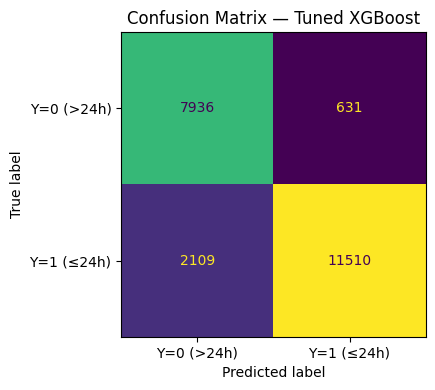

In [23]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_tuned, ax=ax,
                                         display_labels=['Y=0 (>24h)', 'Y=1 (≤24h)'],
                                         colorbar=False)
ax.set_title('Confusion Matrix — Tuned XGBoost')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 8. Feature Importances

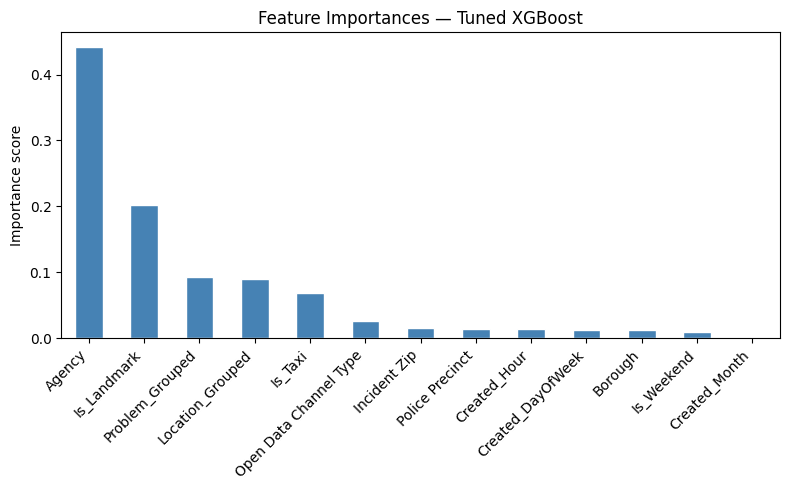


Top-10 features:
Agency                    0.441941
Is_Landmark               0.202664
Problem_Grouped           0.093450
Location_Grouped          0.090049
Is_Taxi                   0.068185
Open Data Channel Type    0.026196
Incident Zip              0.015940
Police Precinct           0.013557
Created_Hour              0.013540
Created_DayOfWeek         0.013070
dtype: float32


In [24]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importances — Tuned XGBoost')
ax.set_ylabel('Importance score')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()

print("\nTop-10 features:")
print(importances.head(10))

## 9. (Optional) Predict on Test Set

In [28]:
# ── UPDATE THIS PATH ─────────────────────────────────────────────────────────
PATH_TEST = r"C:\Users\mfmat\Downloads\ML project data (1)\ML project data\test.csv"
# ─────────────────────────────────────────────────────────────────────────────

import os
if os.path.exists(PATH_TEST):
    df_test = pd.read_csv(PATH_TEST)
    if "Unnamed: 0" in df_test.columns:
        df_test = df_test.drop(columns=["Unnamed: 0"])

    # ----- Apply the same feature engineering -----
    df_test['Created Date'] = pd.to_datetime(df_test['Created Date'], format=date_fmt, errors='coerce')
    if 'Closed Date' in df_test.columns:
        df_test['Closed Date'] = pd.to_datetime(df_test['Closed Date'], format=date_fmt, errors='coerce')


    df_test['Problem_Grouped']  = df_test[problem_col].apply(group_problem)
    df_test['Location_Grouped'] = df_test['Location Type'].apply(group_location)
    df_test['Is_Landmark']      = df_test['Landmark'].notna().astype(int)
    df_test['Is_Taxi']          = df_test['Vehicle Type'].notna().astype(int)
    df_test['Created_Hour']     = df_test['Created Date'].dt.hour
    df_test['Created_DayOfWeek']= df_test['Created Date'].dt.dayofweek
    df_test['Created_Month']    = df_test['Created Date'].dt.month
    df_test['Is_Weekend']       = df_test['Created_DayOfWeek'].isin([5, 6]).astype(int)

    X_test = df_test.drop(columns=features_to_drop + ['Y'], errors='ignore')

    for col in cat_cols:
        X_test[col] = X_test[col].fillna('__MISSING__')
        # Map unseen labels to the __MISSING__ class
        known = set(le_dict[col].classes_)
        X_test[col] = X_test[col].apply(lambda v: v if v in known else '__MISSING__')
        X_test[col] = le_dict[col].transform(X_test[col])

    test_proba = best_model.predict_proba(X_test)[:, 1]
    test_pred  = best_model.predict(X_test)

    submission = pd.DataFrame({'Y_pred': test_pred, 'Y_proba': test_proba})
    submission.to_csv('xgb_submission.csv', index=False)
    print(f"Saved {len(submission):,} predictions → xgb_submission.csv")
    print(submission.head())
else:
    print(f"Test file not found at '{PATH_TEST}' — skipping.")

Saved 27,733 predictions → xgb_submission.csv
   Y_pred   Y_proba
0       0  0.220679
1       0  0.012555
2       0  0.099107
3       1  0.514726
4       0  0.019757
